# Jawablah poin-poin assignment berikut
#### perhatikan dengan baik apa yang diminta pada soal

# 1. Anda bekerja sebagai seorang data scientist, atasan anda mengirimkan anda data kepada anda dan meminta untuk memberikan analisa dengan menggunakan semua metode pada data manipulation berikut :
- a. Filtering
- b. Sorting
- c. Grouping / Aggregasi
- d. Join / Merging
- e. Pivot
- f. Crosstab
- g. Appending
- h. Mengeksplor terkait dengan operasi pada Datetime (week, day, dan sebagainya)
### Notes : Sebelum menjawab permintaan diatas, pertama-tama awali dengan mengajukan pertanyaan analisa terlebih dahulu dan tulis insight dari yang anda dapat, **pertanyaan analisa dilakukan pada semua metode data manipulation diatas**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
file_path = ('/content/drive/MyDrive/DATA ANALYST/Data Manipulation/supermarket_sales.csv')

data = pd.read_csv (file_path)
data.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


In [ ]:
data.isna().sum()

,0
Invoice ID,0
Branch,0
City,0
Customer type,0
Gender,0
Product line,0
Unit price,0
Quantity,0
Tax 5%,0
Total,0


Setelah di cek, data sudah bersih, tidak ada yang NaN/missing value, bisa lanjut ke tahap manipulasi data


a. Filtering
"Atasan ingin melihat penjualan Produk "Sport and travel" pada kota Yangon


In [ ]:
data[
    (data["Product line"] == "Sports and travel") & (data["City"]=="Yangon")
    ][["Total","Rating","Quantity"]].describe()

,Total,Rating,Quantity
count,59.000000,59.000000,59.000000
mean,328.350839,7.257627,5.644068
std,235.076176,1.693314,2.839152
min,16.107000,4.100000,1.000000
25%,148.527750,6.000000,3.500000
50%,271.278000,7.400000,5.000000
75%,465.990000,8.650000,7.500000
max,926.950500,9.900000,10.000000


Berdasarkan hasil analisis, pada kategori produk Sports and travel di kota Yangon, terdapat 59 transaksi yang tercatat. Rata-rata total transaksi sebesar 328.35 dengan rata-rata jumlah pembelian sebanyak 5-6 produk per transaksi. Selain itu, rata-rata rating pelanggan berada pada angka 7.26 yang menunjukkan tingkat kepuasan pelanggan cukup baik terhadap produk dalam kategori ini.

Secara keseluruhan, kategori Sports and travel di Yangon punya potensi penjualan yang baik dengan tingkat kepuasan pelanggan yang relatif positif, sehingga kategori ini dapat dipertahankan dan dikembangkan.

b. Sorting "Atasan ingin melihat Total harga tertinggi dari suatu produk yang terjual"


In [ ]:
data.sort_values(by="Total", ascending = False)[["Product line", "Total","Quantity"]].head()

,Product line,Total,Quantity
350,Fashion accessories,1042.65,10
167,Fashion accessories,1039.29,10
557,Food and beverages,1034.46,10
699,Home and lifestyle,1023.75,10
996,Home and lifestyle,1022.49,10


Berdasarkan hasil analisis, Total penjualan tertinggi yang dibayarkan customer berada pada product line "Fashion Accessories" dengan total 1042.65 dengan penjualan sebanyak 10 produk. Namun dari 5 transaksi tertinggi, total penjualan yang didapat tidak berbeda signifikan, dengan quantity yang sama, total penjualan yang didapat dari setiap product line pun relatif sama.


c. Grouping/Aggregasi "Atasan ingin melihat rata-rata rating tertinggi pada suatu produk line"

In [ ]:
data.groupby("Product line")["Rating"].mean().sort_values(ascending=False)

,Rating
Product line,
Food and beverages,7.113218
Fashion accessories,7.029213
Health and beauty,7.003289
Electronic accessories,6.924706
Sports and travel,6.916265
Home and lifestyle,6.837500


Berdasarkan analisis menggunakan metode grouping, dari kelima produk yang terjual selama 1 tahun, rata-rata rating yang didapatkan dari customer untuk setiap product line seimbang, masing-masing product memiliki rata-rata rating di 6-7. Ini menunjukkan bahwa produk sudah baik, namun perlu ditingkatkan kembali dari segi kualitas produknya. Agar rata-rata rating yang didapat bisa meningkat di tahun berikutnya.

d. Join/Merging "Atasan ingin melihat kategory produk dengan Quantity terbanyak"

In [ ]:
data_branch = pd.read_csv ('/content/drive/MyDrive/DATA ANALYST/Data Manipulation/Copy of branch_info.csv')
data_product = pd.read_csv ('/content/drive/MyDrive/DATA ANALYST/Data Manipulation/Copy of product_info.csv')

merge_data = pd.merge(data,data_product,on="Product line", how="inner")
merge_data2 = pd.merge(merge_data,data_branch,on="Branch", how="inner")
display("Inner join:\n", merge_data2.head())

'Inner join:\n'

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,...,cogs,gross margin percentage,gross income,Rating,Category,Supplier,Warranty (months),Region,Manager,Opened Year
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,...,522.83,4.761905,26.1415,9.1,Beauty,Supplier A,12,South,Alice,2015
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,...,76.40,4.761905,3.8200,9.6,Electronics,Supplier B,24,North,Charlie,2016
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,...,324.31,4.761905,16.2155,7.4,Home,Supplier C,18,South,Alice,2015
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,...,465.76,4.761905,23.2880,8.4,Beauty,Supplier A,12,South,Alice,2015
4,699-14-3026,C,Naypyitaw,Normal,Male,Electronic accessories,85.39,7,29.8865,627.6165,...,597.73,4.761905,29.8865,4.1,Electronics,Supplier B,24,North,Charlie,2016


In [ ]:
merge_data2.groupby("Category")["Quantity"].sum().sort_values(ascending=False)

,Quantity
Category,
Electronics,971
Home,911
Beauty,854


Berdasarkan analisis yang didapatkan, performa penjualan dalam Quantity tertinggi jatuh kepada kategori Electronics. Dengan perbedaan jumlah yang cukup signifikan, menunjukkan bahwa perusahaan ini lebih banyak digemari customer pada bidang/kategori electronics. Namun penjualan Home dan Beauty juga masih tinggi sehingga ketiganya masih berjalan baik dalam penjualan.

e. Pivot "Atasan ingin melihat gross income dari product line yang didapat dari setiap kota"

In [ ]:
data_pivot = data.pivot_table(
    index="Product line",
    values="gross income",
    columns="City",
    aggfunc="sum",
    fill_value=0
)
data_pivot


City,Mandalay,Naypyitaw,Yangon
Product line,,,
Electronic accessories,811.9735,903.2845,872.2435
Fashion accessories,781.5865,1026.6700,777.7385
Food and beverages,724.5185,1131.7550,817.2905
Health and beauty,951.4600,791.2060,599.8930
Home and lifestyle,835.6745,661.6930,1067.4855
Sports and travel,951.8190,750.5680,922.5095


In [ ]:
data_pivot.idxmax(axis=1)

,0
Product line,
Electronic accessories,Naypyitaw
Fashion accessories,Naypyitaw
Food and beverages,Naypyitaw
Health and beauty,Mandalay
Home and lifestyle,Yangon
Sports and travel,Mandalay


Berdasarkan hasil pivot table, setiap kota memiliki kontribusi gross income (Profit kotor) yang berbeda pada masing-masing product line. Beberapa kategori produk menunjukkan performa yang lebih tinggi di kota tertentu, yang mengindikasikan adanya perbedaan preferensi pelanggan pada setiap kota.

Berdasarkan data yang didapat, mayoritas kota Naypyitaw mendominasi gross income tertinggi dari 3 product line (Electronic, Fashion, dan FnB). Kota Mandalay memiliki 2 product line (Healthy&Beauty, Sports and Travel) dengan gross income tertinggi, dan kota Yangon dengan gross income tertinggi pada produk Home and Lifestyle.

Product line dengan gross income tertinggi dapat menjadi fokus utama perusahaan dalam meningkatkan strategi pemasaran, pengelolaan stok, serta pengembangan produk pada kota terkait untuk memaksimalkan keuntungan perusahaan.

f. Crosstab "Atasan ingin melihat metode pembayaran tertinggi berdasarkan tiap kota"

In [ ]:
data_ct = pd.crosstab(
    index=data["City"],
   columns=data["Payment"]
)

data_ct

Payment,Cash,Credit card,Ewallet
City,,,
Mandalay,110,109,113
Naypyitaw,124,98,106
Yangon,110,104,126


Berdasarkan hasil dari crosstab, metode penjualan secara transaksi tidak berbeda signifikan, Customer masih menggunakan Metode pembayaran yang seimbang, tidak ada yang mendominasi. Ini menunjukkan bahwa semua metode pembayaran masih efektif untuk digunakan sehingga tidak ada yang perlu di evaluasi.

g. Appending "Ada tambahan sales dari salah satu branch"


In [ ]:
data_append = pd.DataFrame({
    "Invoice ID" :["123-45-6789"],
    "Branch" : ["B"],
    "City" : ["Naypyitaw"],
    "Customer type" : ["Member"],
    "Gender" : ["Male"],
    "Product line" : ["Electronic accessories"],
    "Unit price" : [15.28],
    "Quantity" : [5],
    "Tax 5%" : [26.1415],
    "Total" : [80.2200],
    "Date" : ["2/19/2019"],
    "Time" : ["20:00"],
    "Payment" : ["Cash"],
    "cogs" : [76.40],
    "gross margin percentage" : [4.761905],
    "gross income" :[3.8200],
    "Rating" : [9.6]
})
df_combined = pd.concat ([data, data_append], ignore_index=True)
display(df_combined)

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,303-96-2227,B,Mandalay,Normal,Female,Home and lifestyle,97.38,10,48.6900,1022.4900,3/2/2019,17:16,Ewallet,973.80,4.761905,48.6900,4.4
997,727-02-1313,A,Yangon,Member,Male,Food and beverages,31.84,1,1.5920,33.4320,2/9/2019,13:22,Cash,31.84,4.761905,1.5920,7.7
998,347-56-2442,A,Yangon,Normal,Male,Home and lifestyle,65.82,1,3.2910,69.1110,2/22/2019,15:33,Cash,65.82,4.761905,3.2910,4.1
999,849-09-3807,A,Yangon,Member,Female,Fashion accessories,88.34,7,30.9190,649.2990,2/18/2019,13:28,Cash,618.38,4.761905,30.9190,6.6


In [ ]:
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1001 non-null   object 
 1   Branch                   1001 non-null   object 
 2   City                     1001 non-null   object 
 3   Customer type            1001 non-null   object 
 4   Gender                   1001 non-null   object 
 5   Product line             1001 non-null   object 
 6   Unit price               1001 non-null   float64
 7   Quantity                 1001 non-null   int64  
 8   Tax 5%                   1001 non-null   float64
 9   Total                    1001 non-null   float64
 10  Date                     1001 non-null   object 
 11  Time                     1001 non-null   object 
 12  Payment                  1001 non-null   object 
 13  cogs                     1001 non-null   float64
 14  gross margin percentage 

Data baru dari perusahaan pada tanggal 12 Desember 2019 ditambahkan dengan metode concat/appending, metode ini berguna untuk analisis yang lebih lengkap terhadap keseluruhan transaksi. Penggabungan data ini membantu perusahaan melihat performa penjualan secara lebih menyeluruh tanpa memisahkan periode atau sumber data yang berbeda.

h. Mengeksplor terkait dengan operasi pada Datetime (week, day, dan sebagainya) “Bulan apa yang memiliki total penjualan tertinggi?”

In [ ]:
df_combined["Date"] = pd.to_datetime(df_combined["Date"])
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Invoice ID               1001 non-null   object        
 1   Branch                   1001 non-null   object        
 2   City                     1001 non-null   object        
 3   Customer type            1001 non-null   object        
 4   Gender                   1001 non-null   object        
 5   Product line             1001 non-null   object        
 6   Unit price               1001 non-null   float64       
 7   Quantity                 1001 non-null   int64         
 8   Tax 5%                   1001 non-null   float64       
 9   Total                    1001 non-null   float64       
 10  Date                     1001 non-null   datetime64[ns]
 11  Time                     1001 non-null   object        
 12  Payment                  1001 non-

In [ ]:
df_combined["Month"] = df_combined['Date'].dt.month_name()
sales_month = df_combined.groupby("Month")["Total"].sum()
sales_month.sort_values(ascending=False)


,Total
Month,
January,116291.868
March,109455.507
February,97299.594


Berdasarkan hasil operasi Datetime dan mengkombinasikan dengan penjualan di tiap bulannya, didapatkan bahwa penjualan di bulan januari menjadi yang tertinggi dibanding bulan-bulan lainnya. Namun Bulan lain pun masih memiliki penjualan yang baik, tetapi secara grafik cenderung terus menurun, sehingga perlu adanya evaluasi yang mendalam terkait performa penjualan setiap bulannya. Untuk upaya menghindari penurunan yang konsisten dan bisa meningkat dibanding bulan sebelumnya.

# 2. Standar Scaller for Exploratory Data Analysis ?
`clue` : lakukan tanpa splitting dataset ke train dan test
- lakukan pada kolom Total, Unit Price, dan tambahkan 2 kolom lainnya
- dan tulis insight dari yang anda dapat dari grafik tersebut

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler
scaler_std = StandardScaler()
data_std = data.copy()
cols = ["Total", "Unit price", "Quantity", "gross income"]
data_std[cols] = scaler_std.fit_transform(data[cols])

display(data_std.head())

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,0.718160,0.509930,26.1415,0.919607,1/5/2019,13:08,Ewallet,522.83,4.761905,0.919607,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,-1.525303,-0.174540,3.8200,-0.987730,3/8/2019,10:29,Cash,76.40,4.761905,-0.987730,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,-0.352781,0.509930,16.2155,0.071446,3/3/2019,13:23,Credit card,324.31,4.761905,0.071446,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,0.096214,0.852165,23.2880,0.675780,1/27/2019,20:33,Ewallet,465.76,4.761905,0.675780,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,1.156959,0.509930,30.2085,1.267125,2/8/2019,10:37,Ewallet,604.17,4.761905,1.267125,5.3


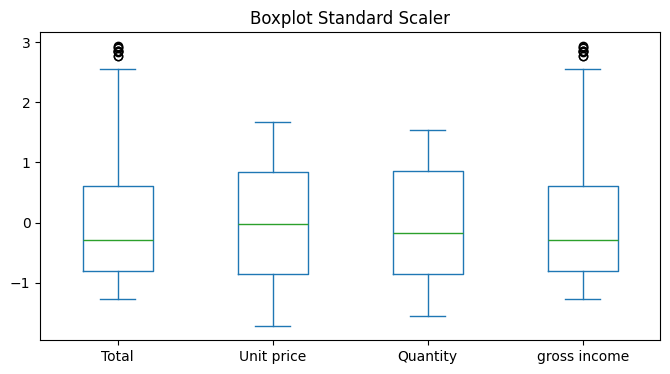

In [ ]:
data_std[cols].plot(
    kind="box",
    figsize=(8,4)
)

plt.title("Boxplot Standard Scaler")
plt.show()

Berdasarkan hasil boxplot setelah dilakukan Standard Scaling, seluruh variabel numerik berhasil distandarisasi dengan median yang berada di sekitar angka 0. Hal ini menunjukkan bahwa proses scaling berhasil menyamakan skala data sehingga distribusi antar variabel menjadi lebih mudah dibandingkan.

Variabel Total dan gross income masih menunjukkan beberapa outlier yang mengindikasikan adanya transaksi dengan nilai penjualan dan keuntungan yang sangat tinggi dibanding sebagian besar data lainnya. Sementara itu, variabel Unit price dan Quantity memiliki distribusi yang relatif lebih stabil dan tidak menunjukkan outlier yang terlalu ekstrem.

# 3. MinMax Scaller for Exploratory Data Analysis ?
`clue` : lakukan tanpa splitting dataset ke train dan test
- lakukan pada kolom Total, Unit Price, dan tambahkan 2 kolom lainnya
- dan tulis insight dari yang anda dapat dari grafik tersebut

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
scaler_mm = MinMaxScaler()
data_mm = data.copy()
cols2 = ["Total", "Unit price", "cogs", "gross income"]
data_mm[cols2] = scaler_mm.fit_transform(data[cols2])

display(data_mm.head())

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,0.718847,7,26.1415,0.521616,1/5/2019,13:08,Ewallet,0.521616,4.761905,0.521616,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,0.057855,5,3.8200,0.067387,3/8/2019,10:29,Cash,0.067387,4.761905,0.067387,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,0.403316,7,16.2155,0.319628,3/3/2019,13:23,Credit card,0.319628,4.761905,0.319628,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,0.535603,8,23.2880,0.463549,1/27/2019,20:33,Ewallet,0.463549,4.761905,0.463549,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,0.848131,7,30.2085,0.604377,2/8/2019,10:37,Ewallet,0.604377,4.761905,0.604377,5.3


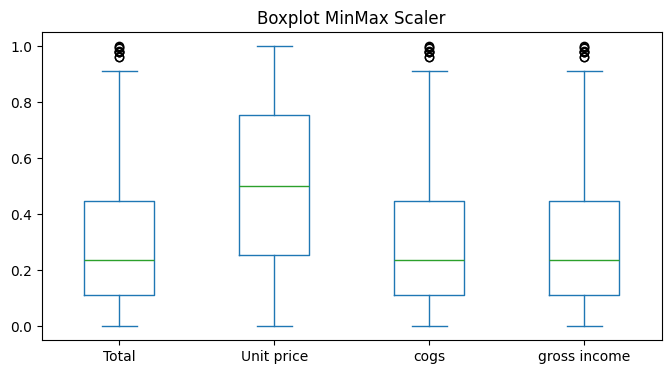

In [ ]:
data_mm[cols2].plot(
    kind="box",
    figsize=(8,4)
)

plt.title("Boxplot MinMax Scaler")
plt.show()

Berdasarkan hasil boxplot setelah dilakukan Min-Max Scaling, seluruh variabel numerik berhasil dinormalisasi ke rentang 0 hingga 1 sehingga distribusi data menjadi lebih mudah dibandingkan antar variabel.

Variabel Total, cogs, dan gross income menunjukkan pola distribusi yang relatif serupa karena ketiganya berkaitan langsung dengan nilai transaksi penjualan. Selain itu, masih terdapat beberapa outlier pada variabel tersebut yang mengindikasikan adanya transaksi dengan nilai yang jauh lebih tinggi dibanding sebagian besar transaksi lainnya.

Sementara itu, variabel Unit price memiliki median yang lebih tinggi dan persebaran data yang cukup stabil, yang menunjukkan bahwa harga satuan produk memiliki distribusi yang lebih merata dibanding variabel transaksi lainnya.

